First 5 Rows
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


Last 5 Rows
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0       

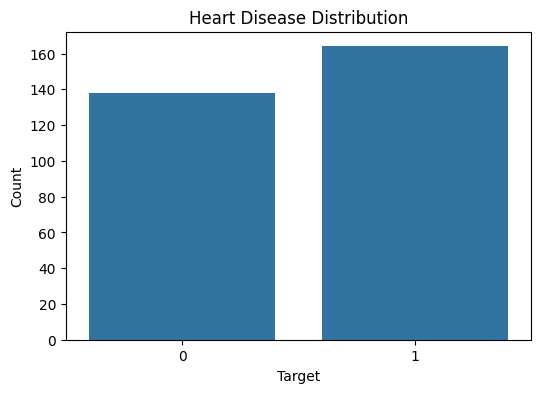

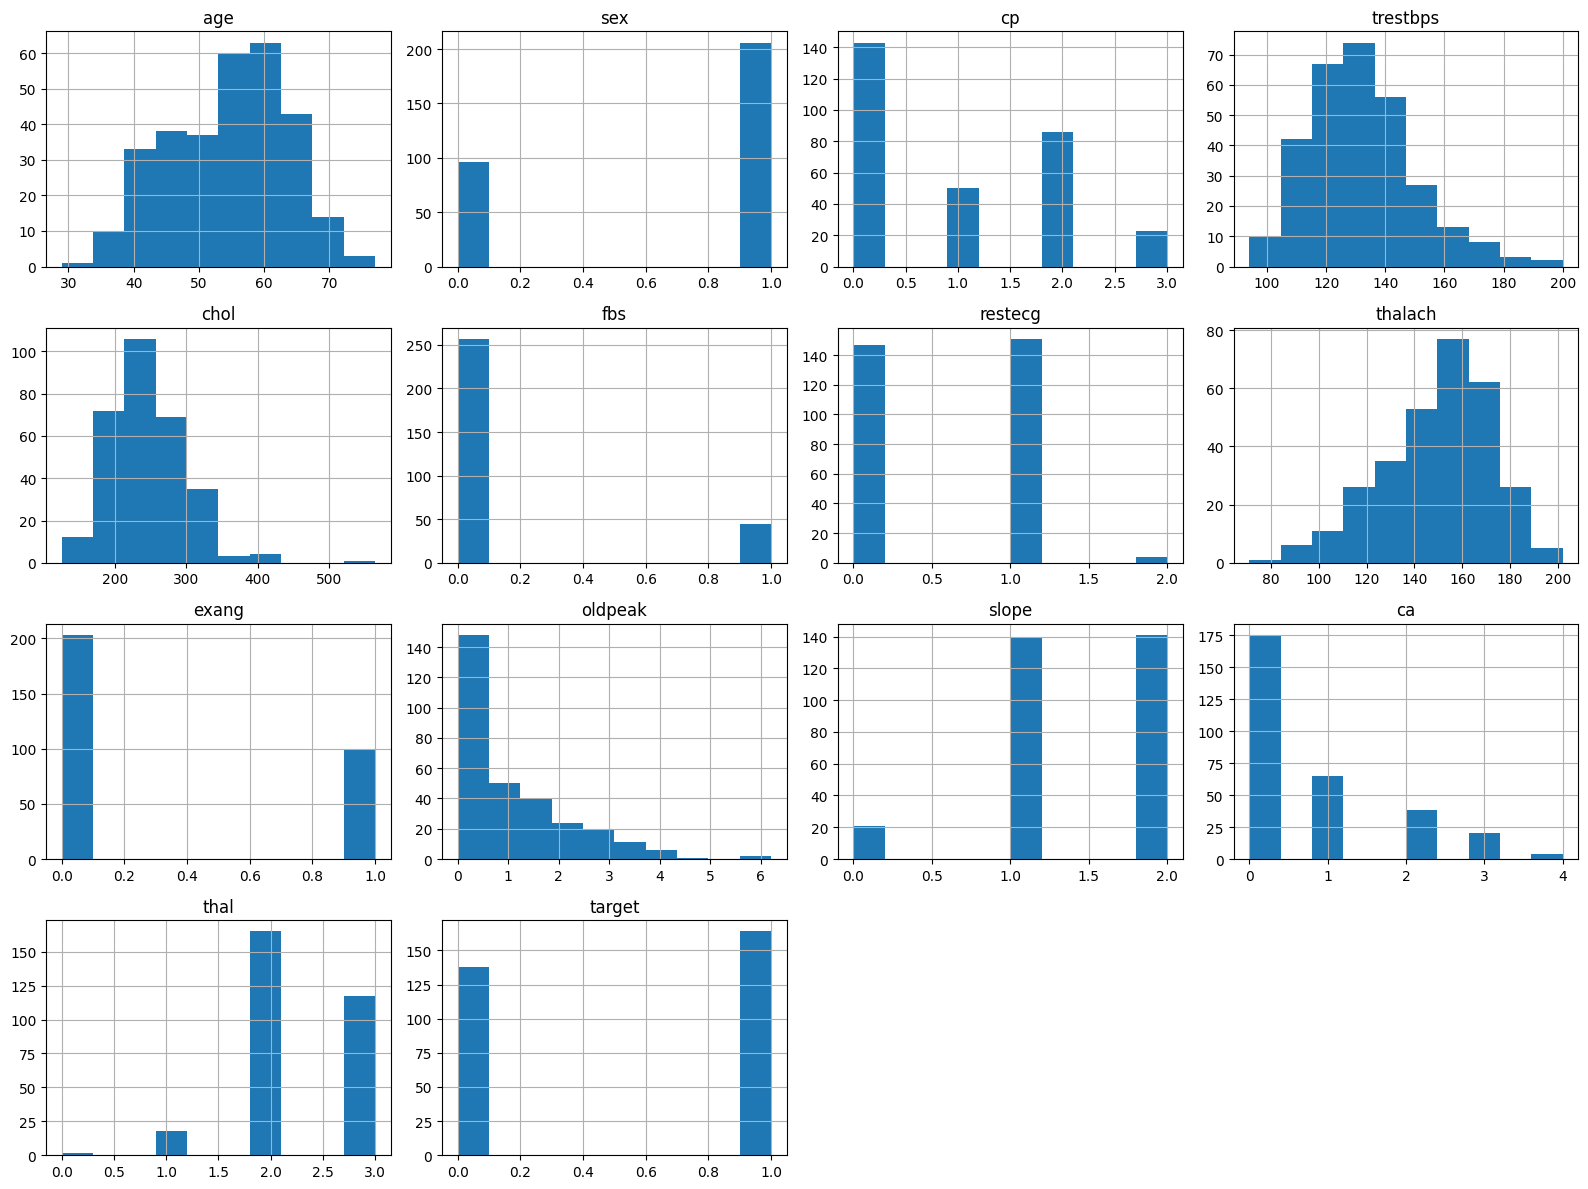

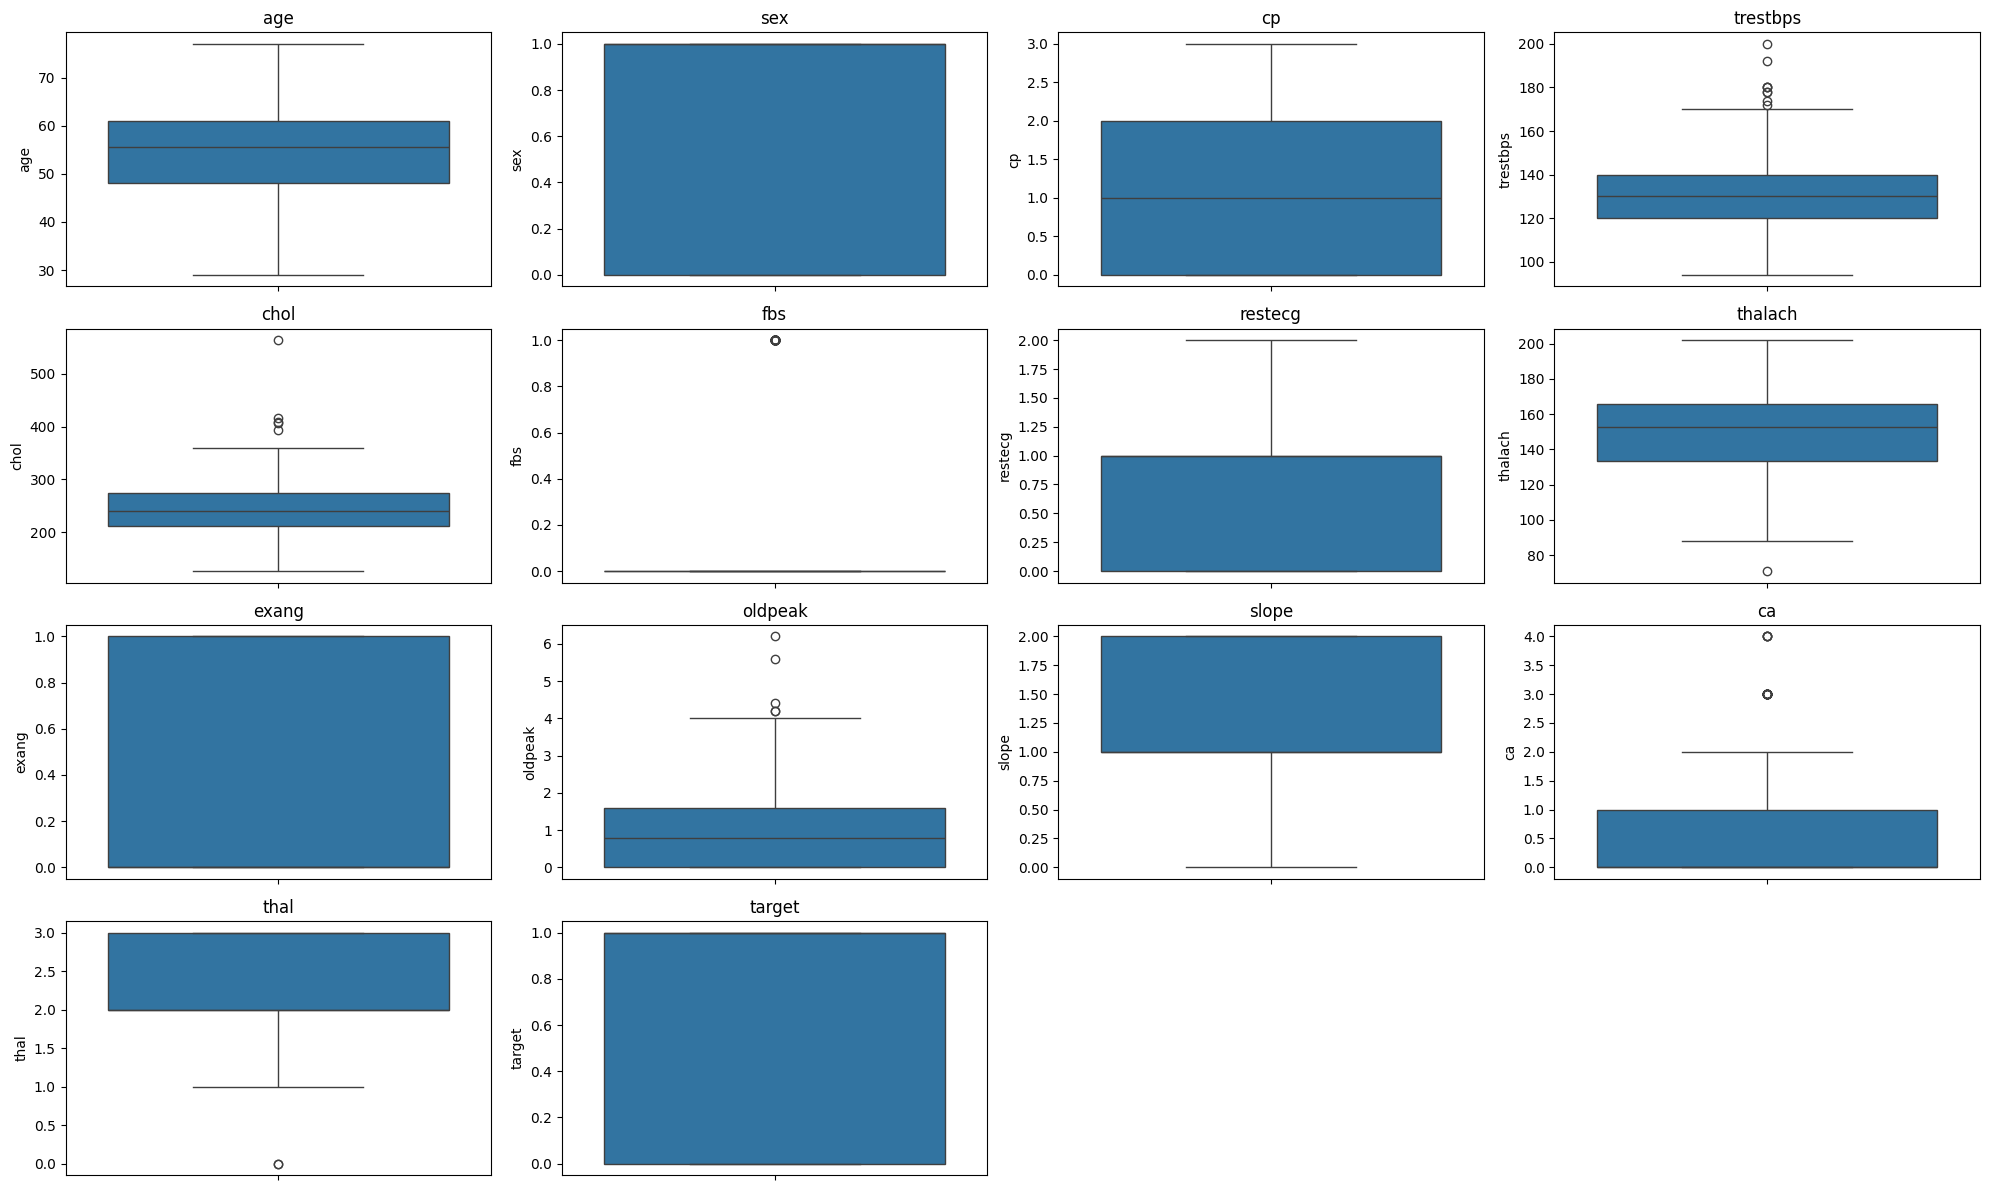

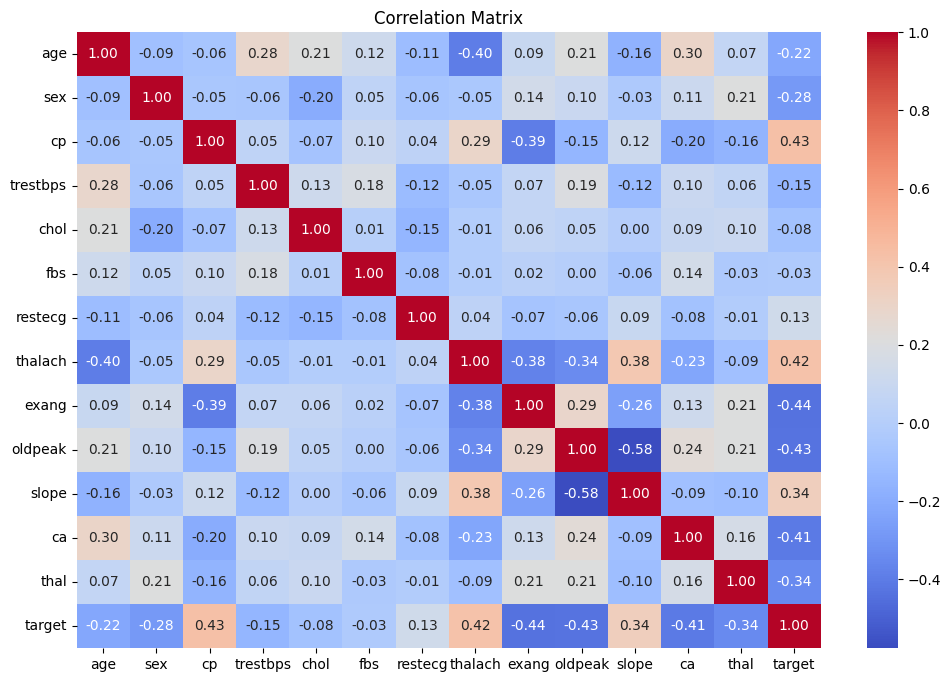

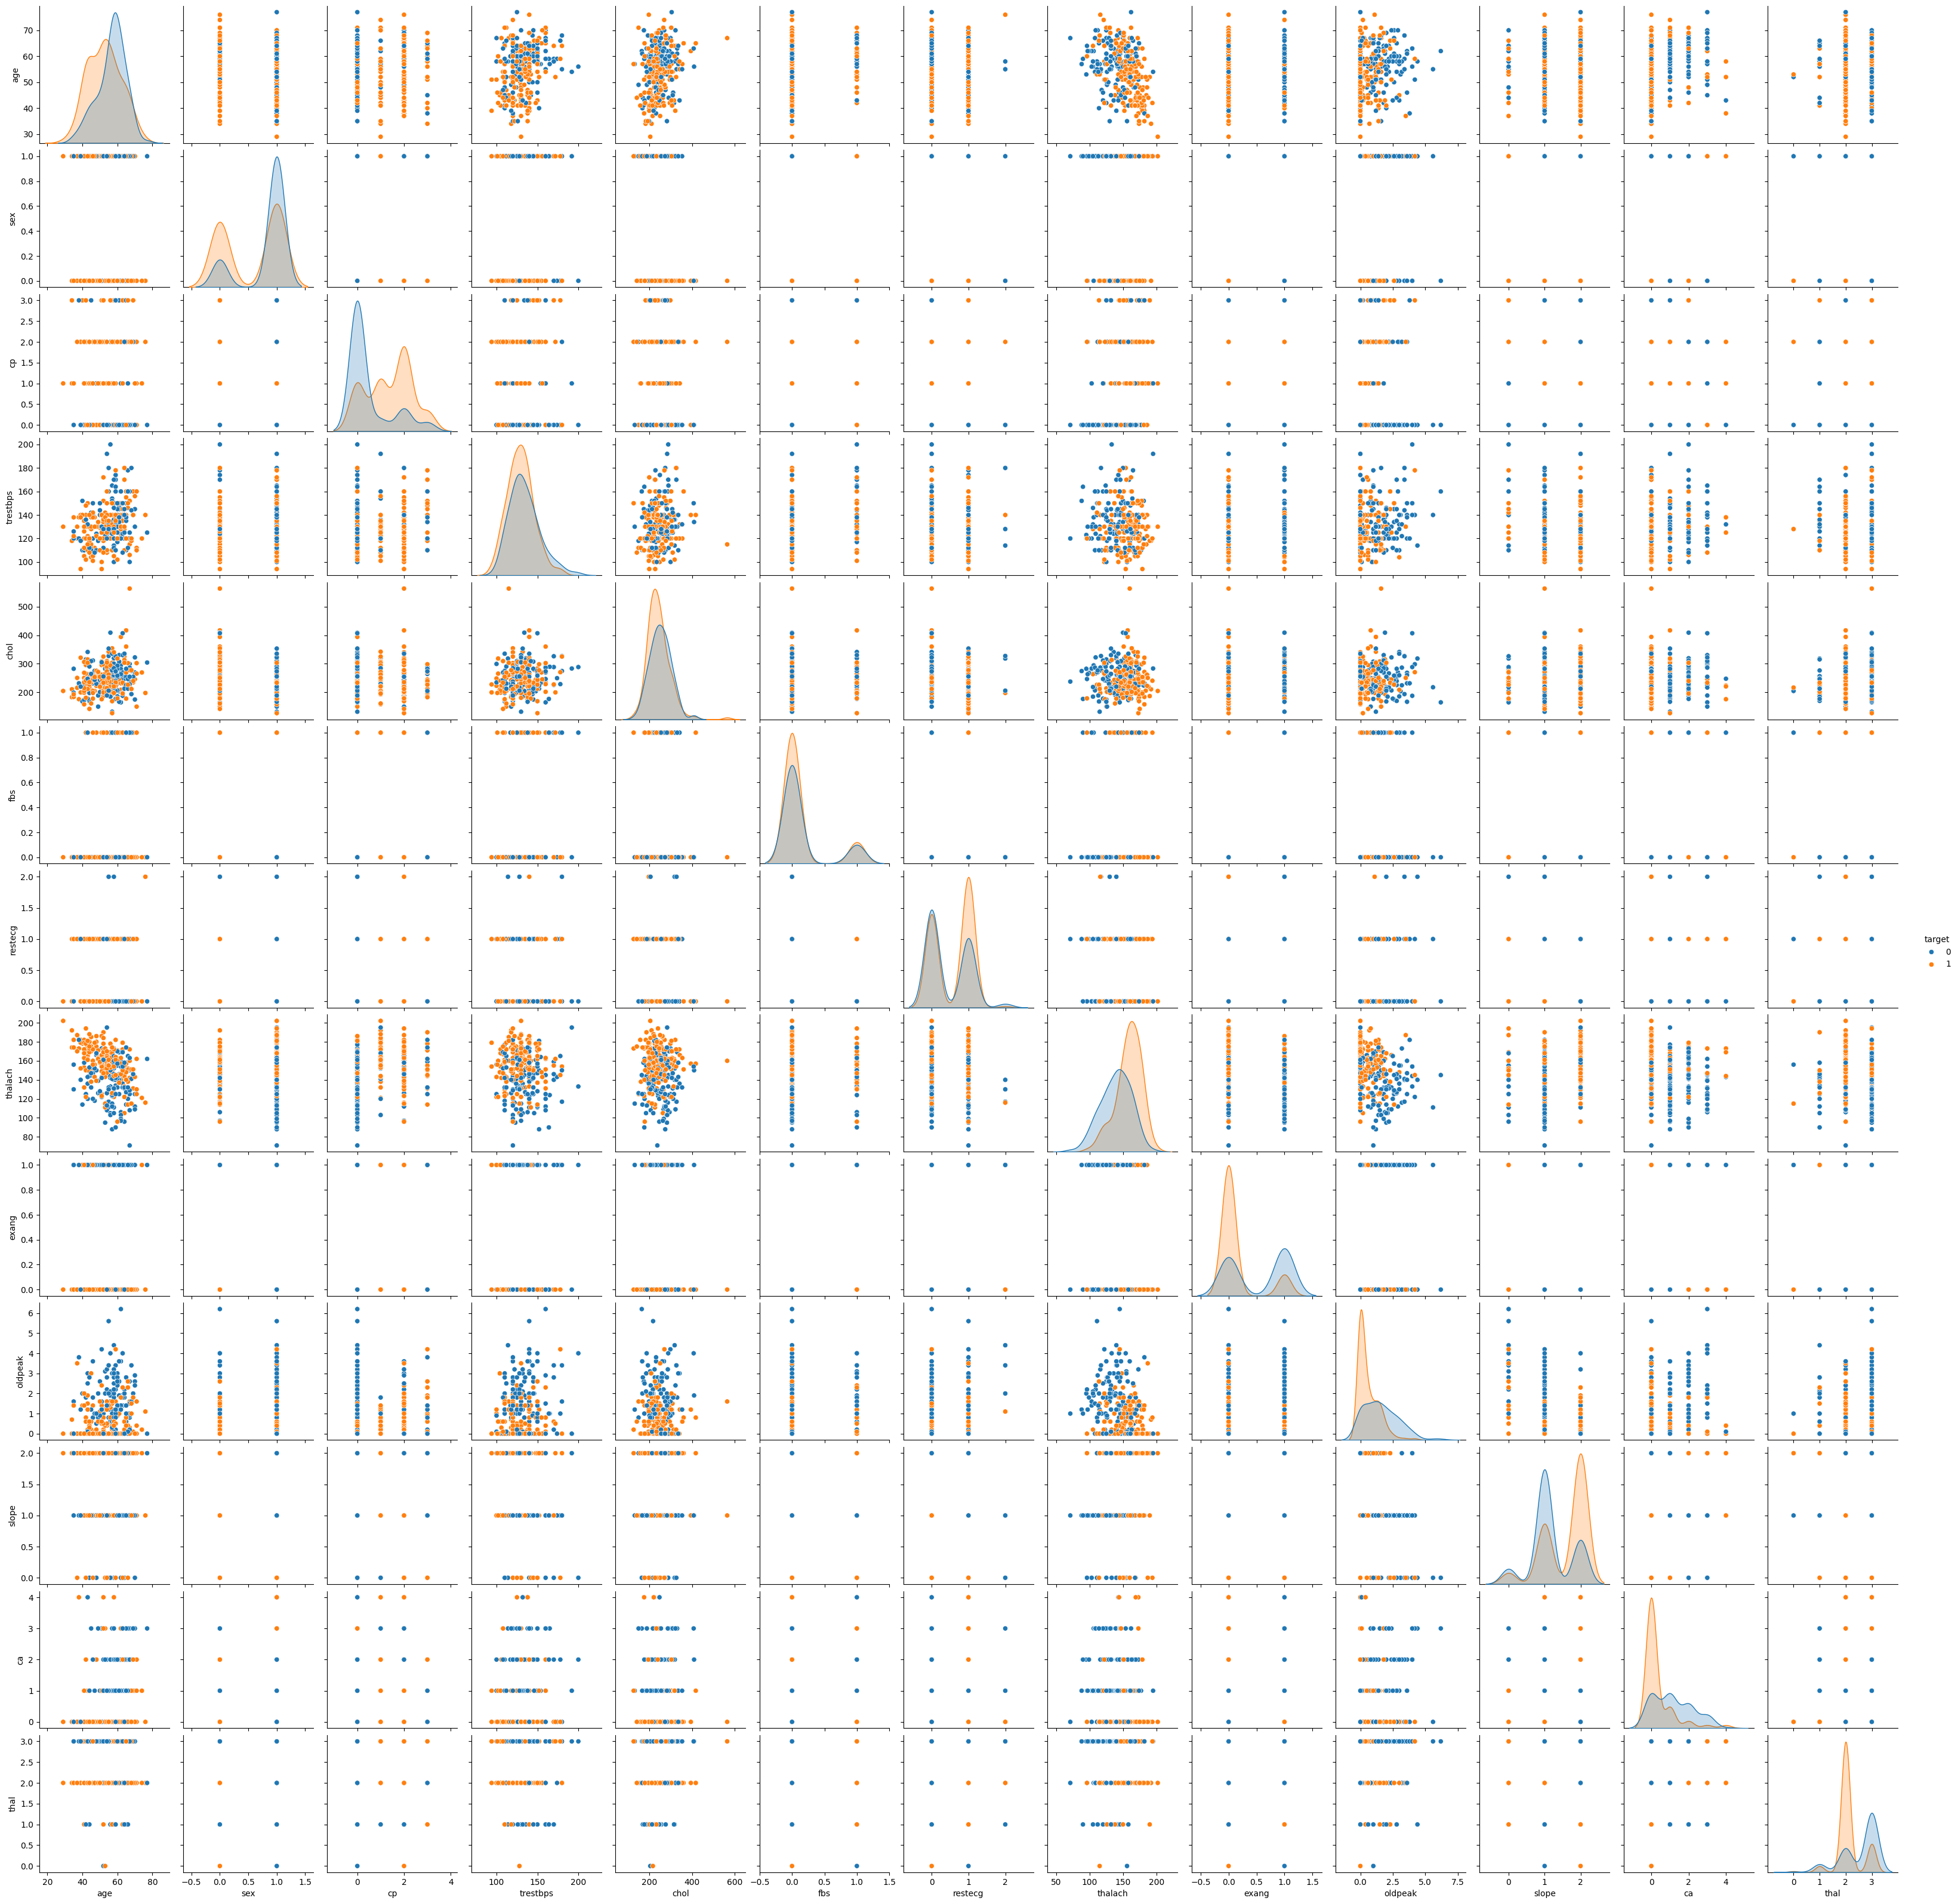


age
[52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]

sex
[1 0]

cp
[0 1 2 3]

trestbps
[125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115  94 200 165 102 105 155 172 164 156 101]

chol
[212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 160 247 239 246
 409 293 180 250 221 200 227 243 311 261 242 205 306 219 353 198 394 183
 237 224 265 313 340 259 270 216 264 276 322 214 273 253 176 284 305 168
 407 290 277 262 195 166 178 141]

fbs
[0 1]

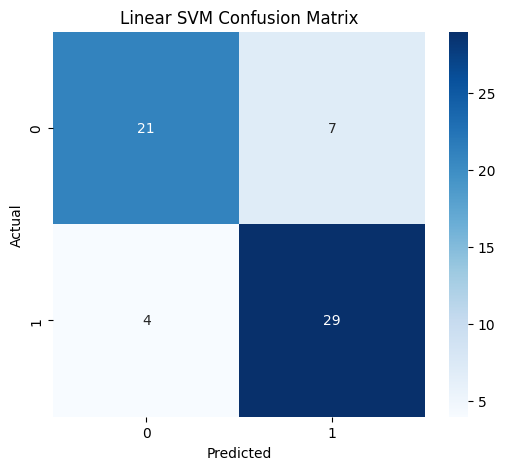

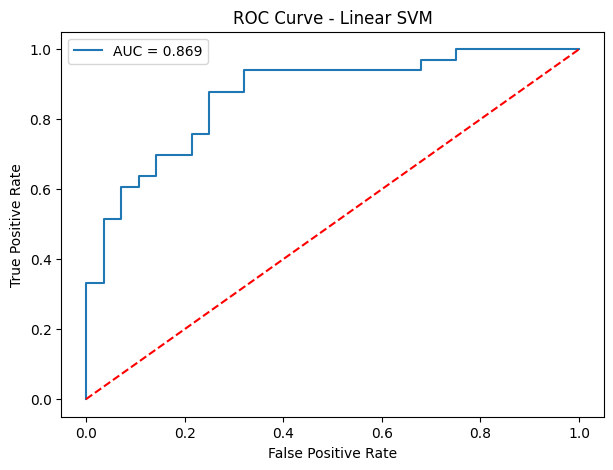

ROC AUC Score : 0.8690476190476191


RBF SVM RESULTS
Accuracy : 0.7704918032786885
Precision: 0.7714285714285715
Recall   : 0.8181818181818182
F1 Score : 0.7941176470588235

Classification Report

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



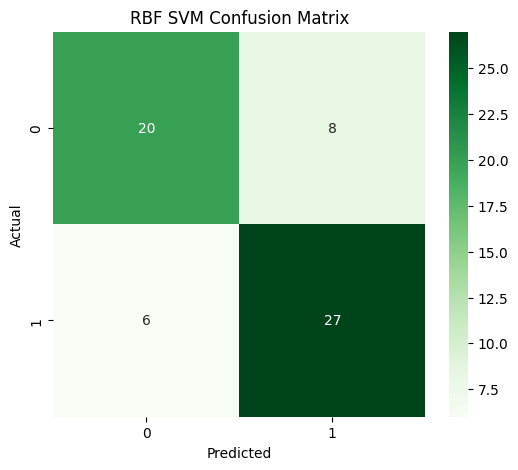

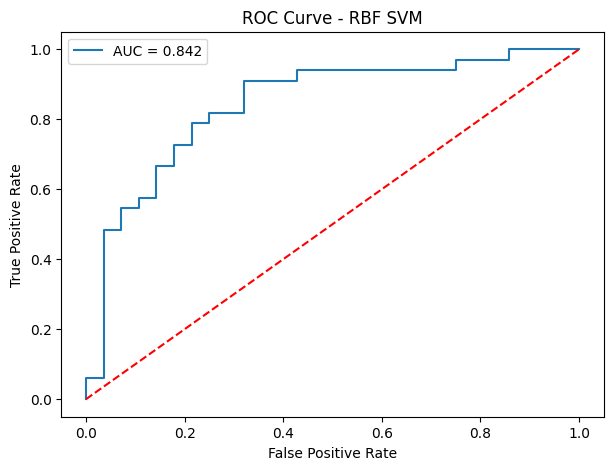

ROC AUC Score : 0.841991341991342
BEST PARAMETERS
{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}

Best Cross Validation Accuracy
0.8339285714285716

Best Model Accuracy
0.8032786885245902

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.71      0.77        28
           1       0.78      0.88      0.83        33

    accuracy                           0.80        61
   macro avg       0.81      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



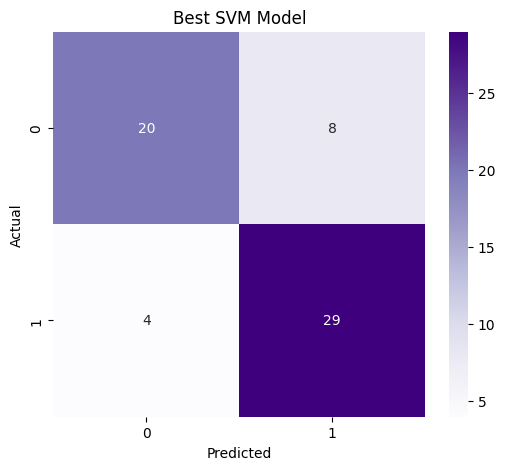

In [ ]:
# ===========================================
# HEART DISEASE PREDICTION USING SVM
# PART 1 - IMPORTS + DATA LOADING + EDA
# ===========================================

# ================================
# 1. IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# ================================
# 2. LOAD DATASET
# ================================

df = pd.read_csv("Heart-dis.csv")

# ================================
# 3. FIRST LOOK AT DATA
# ================================

print("="*60)
print("First 5 Rows")
print("="*60)
print(df.head())

print("\n")

print("="*60)
print("Last 5 Rows")
print("="*60)
print(df.tail())

print("\n")

print("="*60)
print("Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Columns")
print("="*60)
print(df.columns)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)
print(df.info())

print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)
print(df.describe())

# ================================
# 4. CHECK DATA TYPES
# ================================

print("\nData Types\n")
print(df.dtypes)

# ================================
# 5. CHECK MISSING VALUES
# ================================

print("\nMissing Values\n")
print(df.isnull().sum())

# ================================
# 6. CHECK DUPLICATES
# ================================

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:", df.shape)

# ================================
# 7. CHECK TARGET DISTRIBUTION
# ================================

print("\nTarget Value Counts\n")
print(df["target"].value_counts())

# ================================
# 8. CHECK CLASS BALANCE
# ================================

plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

# ================================
# 9. HISTOGRAMS
# ================================

df.hist(figsize=(16,12))

plt.tight_layout()

plt.show()

# ================================
# 10. BOXPLOTS
# ================================

numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(20,12))

for i, col in enumerate(numeric_columns):

    plt.subplot(4,4,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

# ================================
# 11. CORRELATION MATRIX
# ================================

plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# ================================
# 12. PAIRPLOT
# (Can be slow on large datasets)
# ================================

sns.pairplot(
    df,
    hue="target"
)

plt.show()

# ================================
# 13. CHECK UNIQUE VALUES
# ================================

for col in df.columns:

    print(f"\n{col}")

    print(df[col].unique())

# ================================
# 14. CHECK SKEWNESS
# ================================

print("\nSkewness\n")

print(df.skew())

# ================================
# 15. TARGET PERCENTAGE
# ================================

print("\nTarget Percentage")

print(df["target"].value_counts(normalize=True)*100)

# ===========================================
# PART 2 - FEATURE ENGINEERING + SVM
# ===========================================

# ===========================================
# 1. FEATURES (X) AND TARGET (y)
# ===========================================

X = df.drop("target", axis=1)
y = df["target"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

# ===========================================
# 2. TRAIN TEST SPLIT
# ===========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data :", X_train.shape)
print("Testing Data :", X_test.shape)

# ===========================================
# 3. FEATURE SCALING
# ===========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nScaling Completed Successfully")

# ===========================================
# 4. IMPORT SVM
# ===========================================

from sklearn.svm import SVC

# ===========================================
# 5. LINEAR SVM
# ===========================================

linear_svm = SVC(
    kernel="linear",
    random_state=42
)

linear_svm.fit(X_train_scaled, y_train)

print("\nLinear SVM Trained Successfully")

# ===========================================
# 6. RBF SVM
# ===========================================

rbf_svm = SVC(
    kernel="rbf",
    random_state=42
)

rbf_svm.fit(X_train_scaled, y_train)

print("RBF SVM Trained Successfully")

# ===========================================
# 7. PREDICTIONS
# ===========================================

linear_pred = linear_svm.predict(X_test_scaled)

rbf_pred = rbf_svm.predict(X_test_scaled)

print("\nPrediction Completed")

# ===========================================
# PART 3 - MODEL EVALUATION
# ===========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ===========================================
# LINEAR SVM EVALUATION
# ===========================================

print("="*60)
print("LINEAR SVM RESULTS")
print("="*60)

linear_accuracy = accuracy_score(y_test, linear_pred)
linear_precision = precision_score(y_test, linear_pred)
linear_recall = recall_score(y_test, linear_pred)
linear_f1 = f1_score(y_test, linear_pred)

print("Accuracy :", linear_accuracy)
print("Precision:", linear_precision)
print("Recall   :", linear_recall)
print("F1 Score :", linear_f1)

print("\nClassification Report\n")
print(classification_report(y_test, linear_pred))

# ===========================================
# CONFUSION MATRIX
# ===========================================

cm = confusion_matrix(y_test, linear_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ===========================================
# ROC CURVE
# ===========================================

# Need probabilities for ROC Curve
linear_svm_probability = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

linear_svm_probability.fit(X_train_scaled, y_train)

y_prob = linear_svm_probability.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Linear SVM")

plt.legend()

plt.show()

print("ROC AUC Score :", auc)

# ===========================================
# RBF SVM EVALUATION
# ===========================================

print("\n")
print("="*60)
print("RBF SVM RESULTS")
print("="*60)

rbf_accuracy = accuracy_score(y_test, rbf_pred)
rbf_precision = precision_score(y_test, rbf_pred)
rbf_recall = recall_score(y_test, rbf_pred)
rbf_f1 = f1_score(y_test, rbf_pred)

print("Accuracy :", rbf_accuracy)
print("Precision:", rbf_precision)
print("Recall   :", rbf_recall)
print("F1 Score :", rbf_f1)

print("\nClassification Report\n")
print(classification_report(y_test, rbf_pred))

# ===========================================
# CONFUSION MATRIX
# ===========================================

cm = confusion_matrix(y_test, rbf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Greens",
    fmt="d"
)

plt.title("RBF SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ===========================================
# ROC CURVE
# ===========================================

rbf_probability = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

rbf_probability.fit(X_train_scaled, y_train)

y_prob = rbf_probability.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - RBF SVM")

plt.legend()

plt.show()

print("ROC AUC Score :", auc)

# ===========================================
# PART 4 - HYPERPARAMETER TUNING
# ===========================================

from sklearn.model_selection import GridSearchCV

# ===========================================
# PARAMETER GRID
# ===========================================

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [1, 0.1, 0.01, 0.001],
    "kernel": ["linear", "rbf"]
}

# ===========================================
# GRID SEARCH
# ===========================================

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("="*60)
print("BEST PARAMETERS")
print("="*60)

print(grid.best_params_)

print("\nBest Cross Validation Accuracy")
print(grid.best_score_)

# ===========================================
# BEST MODEL
# ===========================================

best_model = grid.best_estimator_

# ===========================================
# PREDICTION
# ===========================================

best_prediction = best_model.predict(X_test_scaled)

# ===========================================
# ACCURACY
# ===========================================

from sklearn.metrics import accuracy_score

best_accuracy = accuracy_score(y_test, best_prediction)

print("\nBest Model Accuracy")

print(best_accuracy)

# ===========================================
# CLASSIFICATION REPORT
# ===========================================

from sklearn.metrics import classification_report

print("\nClassification Report\n")

print(classification_report(y_test, best_prediction))

# ===========================================
# CONFUSION MATRIX
# ===========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Purples",
    fmt="d"
)

plt.title("Best SVM Model")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

                   Model  Accuracy
0             Linear SVM  0.819672
1                RBF SVM  0.770492
2  Best GridSearch Model  0.803279


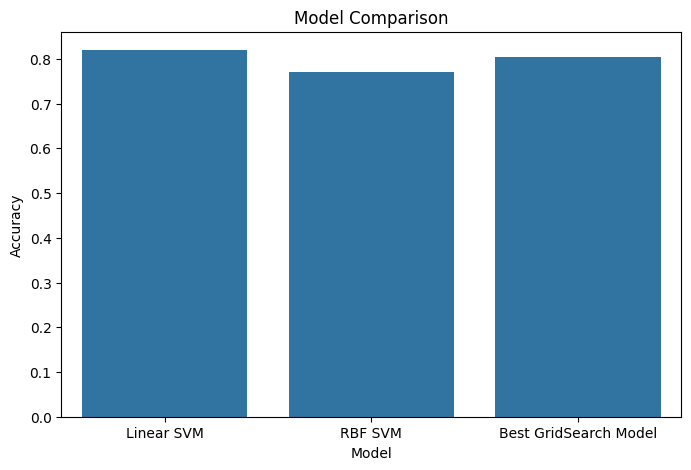

In [ ]:
# ===========================================
# MODEL COMPARISON
# ===========================================

comparison = pd.DataFrame({

    "Model":[
        "Linear SVM",
        "RBF SVM",
        "Best GridSearch Model"
    ],

    "Accuracy":[
        linear_accuracy,
        rbf_accuracy,
        best_accuracy
    ]

})

print(comparison)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.title("Model Comparison")

plt.show()

In [ ]:
# ===========================================
# NEW PATIENT
# ===========================================

sample = [[
    63,
    1,
    3,
    145,
    233,
    1,
    0,
    150,
    0,
    2.3,
    0,
    0,
    1
]]

sample = scaler.transform(sample)

prediction = best_model.predict(sample)

if prediction[0] == 1:

    print("Heart Disease Detected")

else:

    print("No Heart Disease")

import joblib

joblib.dump(best_model,"svm_heart_model.pkl")

joblib.dump(scaler,"scaler.pkl")

print("Model Saved Successfully")

import joblib

model = joblib.load("svm_heart_model.pkl")

scaler = joblib.load("scaler.pkl")

sample = [[
    63,
    1,
    3,
    145,
    233,
    1,
    0,
    150,
    0,
    2.3,
    0,
    0,
    1
]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

print(prediction)

Heart Disease Detected
Model Saved Successfully
[1]
